<a href="https://colab.research.google.com/github/clavoie1/clavoie1/blob/main/Amazon_Product_Reviews_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Decision Tree</h1>

<h2>Business Understanding: Amazon Product Reviews</h2>
According to <a href=https://redstagfulfillment.com/leadership>Red Stag Fulfillment</a>, a Third-party logistics company specializing in heavy, oversized, and high-priced goods, the average number of reviews across all products on <a href=https://amazon.com>Amazon</a> is around 40, with the median number of reviews being just under 30. Products in the electronics category have an average of over 150 reviews per item. The percent of reviews distributed across the percent of products is:
<ul>
<li>0-10 reviews: 35% of all products</li>
<li>11-50 reviews: 40% of all products</li>
<li>51-100 reviews: 15% of all products</li>
<li>101-500 reviews: 8% of all products</li>
<li>500+ reviews: 2% of all products</li>
</ul>
Item feedback is significant for influencing future purchases, with over 65% of potential customers consulting at least 50 reviews prior to committing to a purchase. At about 210 words per review, the average Amazon consumer makes a purchase after reading approximately 11,000 words about the product.
To which features in a review are customers paying most attention? In addition to the star rating system, which Amazon now allows customers to provide with no additional feedback, for what characteristics are potential purchasers looking as they - well, review - feedback from current product users?



In [1]:
#Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

<h2>Data Understanding</h2>
50 reviews were collected from eight (8) different fitness tracker rings listed on Amazon.
<ul>
<li>Oura 4</li>
<li>Oura 4 - Ceramic</li>
<li>Samsung Galaxy</li>
<li>RingConn Gen 2 Air</li>
<li>RENPHO Lynx</li>
<li>Elenva Smart Ring</li>
<li>Anarow Fitness Tracker Ring</li>
<li>BIEMHA Fitness Tracker Ring</li>
</ul>
Text of the reviews was collected, though it was not used in the analysis but was used instead for word count. Information was collected on how many users found the review helpful, number-of-stars-rating, Prime-eligibility, whether reviews contained photos, whether reviews included positive (P) or negative (C) feedback, or a balance of both (B) and the date the product review was posted. An addition column included whether we as potential purchasers found the review helpful.

In [3]:
#Load the dataset
file_path = 'amazon_reviews.xlsx'
df = pd.read_excel(file_path)
print(df.head())
print(df.info())
print(df.describe())

           Device                                           Title  \
0  Oura 4 Ceramic  Wasn’t Sure at First—Now I’m So Glad I Have It   
1  Oura 4 Ceramic      Smart, Sleek, and Surprisingly Insightful!   
2  Oura 4 Ceramic                       Amazing wellness tracker!   
3  Oura 4 Ceramic  A Smart Ring That Redefines Wellness Tracking!   
4  Oura 4 Ceramic          Stylish, smart, and super comfortable!   

                                              Review  Helpful  \
0  I wasn’t sure I wanted the Oura Ring 4 Ceramic...        1   
1  I absolutely love my Oura Ring 4! It’s lightwe...        1   
2  I NEVER take this off! I’m into living a healt...        0   
3  The Oura Ring 4 is simply outstanding! Its cer...        1   
4  I absolutely love my Oura Ring 4! The design i...        0   

   Helpful_to_others  Review_length  Star_rating  Prime_eligible  Photos  \
0                  6            175            5               1       0   
1                 35            124       

<h2>Data Preparation</h2>
As part of the determining which features of a review influence a potential purchaser, presence or absence of particular data was important to the model.
</br>Categorical data was binary encoded with a zero (0) to indicate absence of a characteristic or feature, and a one (1) to indicate presence. This includes whether we found the review helpful, Prime-eligibility, and inclusion of a photo in the review.
</br>Other data formats are integers for word length of the reviews, number of potential purchasers who found the review helpful, and number of stars in the rating; and date/time of the review posting.
</br>The spreadsheet itself included the formula for word count so that function was performed prior to reading the data into the dataframe. We used Python functions to create and binary encode a column indicating the presence of value-related keywords, create a column to count days since review was posted using "T" (or current day) for reference, and seperate the feedback column into three (3) separate binary encoded columns.
</br>Descriptive statistics are provided below. There were no significant outliers in the data that required normalizing. Of note is that in the dataset, 74% of reviews were rated as helpful to us as potential purchases. This increases likelihood of a training sample including only reviews categorized as helpful.
</br>The y variable was set to "helpful" and the x variables were "helpful to others", "review length", "star rating", "prime eligible", "photos", "days since review", "only pros", "only cons", "balanced", and "value keywords".
</br>The dataset was divided into 70% training (35 instances) and 30% validation (15 instances) subsets.

In [4]:
#Define fitness ring review "value" keywords
value_keywords = ['price', 'worth', 'cost', 'expensive', 'subscription', 'fee', 'affordable', 'accuracy', 'accurate',
                  'reliability', 'reliable', 'durable', 'durability']

#Create the function to scan the "Review" column
def check_value(text):
    # Convert to string and lowercase so 'Price' and 'price' both count
    text = str(text).lower()
    if any(word in text for word in value_keywords):
        return 1
    else:
        return 0

df['mentions_value'] = df['Review'].apply(check_value)

#Create column to count days since review date, with "T"
df['Review_date'] = pd.to_datetime(df['Review_date'])
ref_date = df['Review_date'].max()
df['days_since_review'] = (ref_date - df['Review_date']).dt.days

#Separate single "Feedback" column into 3 columns
feedback_map = {
    'P': 'only_pros',
    'C': 'only_cons',
    'Y': 'balanced'
}

feedback_descriptive = df['Feedback'].map(feedback_map)
df_encoded = pd.get_dummies(feedback_descriptive, dtype=int)
df = pd.concat([df, df_encoded], axis=1)
df = df.drop('Feedback', axis=1)
print(df.head())
print(df.describe())

           Device                                           Title  \
0  Oura 4 Ceramic  Wasn’t Sure at First—Now I’m So Glad I Have It   
1  Oura 4 Ceramic      Smart, Sleek, and Surprisingly Insightful!   
2  Oura 4 Ceramic                       Amazing wellness tracker!   
3  Oura 4 Ceramic  A Smart Ring That Redefines Wellness Tracking!   
4  Oura 4 Ceramic          Stylish, smart, and super comfortable!   

                                              Review  Helpful  \
0  I wasn’t sure I wanted the Oura Ring 4 Ceramic...        1   
1  I absolutely love my Oura Ring 4! It’s lightwe...        1   
2  I NEVER take this off! I’m into living a healt...        0   
3  The Oura Ring 4 is simply outstanding! Its cer...        1   
4  I absolutely love my Oura Ring 4! The design i...        0   

   Helpful_to_others  Review_length  Star_rating  Prime_eligible  Photos  \
0                  6            175            5               1       0   
1                 35            124       

In [5]:
X = df[['Helpful_to_others', 'Review_length', 'Star_rating', 'Prime_eligible', 'Photos', 'mentions_value', 'days_since_review', 'balanced', 'only_cons', 'only_pros']]
y = df['Helpful']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

<h2>Modeling</h2>
Initial data modeling was conducted using a simple decision tree.
</br>We tested combinations of hyperparameters for accuracy and f1-score including:
<li>criterion: gini, entropy</li>
<li>max_depth: 2, 3, 4, 5</li>
<li>min_samples_leaf: 2, 3, 4, 5</li>
<li>min_samples_split: 2, 3, 4, 5</li>
<li>ccp_alpha: .01, .02</li>
With only 50 instances (35 in the training dataset and 15 in the validation dataset), it was necessary to keep the leaf and split samples small enough to generate multiple iterations of analysis.
</br>Ultimately, the model default values of 1 for the min_samples_leaf and min_samples_split resulted in the highest values. With fewer instances of data, requiring the nodes to contain even 2-3 samples prevented the model from iterating.
</br>Final hyperparameters for the model were gini, max_depth=5, and random_state of 42 (for reproducibility).

In [6]:
#Initialized the model and tested multiple hyperparameter combinations to find the greatest accuracy and f1-score
clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [7]:
#Results of training data
y_pred = clf.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.96      0.98        25

    accuracy                           0.97        35
   macro avg       0.95      0.98      0.97        35
weighted avg       0.97      0.97      0.97        35



In [8]:
#Use the test dataset to assess the performance of the decision tree
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.67      0.57         3
           1       0.91      0.83      0.87        12

    accuracy                           0.80        15
   macro avg       0.70      0.75      0.72        15
weighted avg       0.83      0.80      0.81        15



In [9]:
#Visualize the decision tree
tree_rules = export_text(clf, feature_names=list(X.columns))
print("\nDecision Tree Rules:")
print(tree_rules)


Decision Tree Rules:
|--- Review_length <= 84.50
|   |--- Helpful_to_others <= 1.00
|   |   |--- class: 1
|   |--- Helpful_to_others >  1.00
|   |   |--- class: 0
|--- Review_length >  84.50
|   |--- days_since_review <= 106.50
|   |   |--- Helpful_to_others <= 7.00
|   |   |   |--- days_since_review <= 42.00
|   |   |   |   |--- class: 1
|   |   |   |--- days_since_review >  42.00
|   |   |   |   |--- class: 0
|   |   |--- Helpful_to_others >  7.00
|   |   |   |--- Review_length <= 221.00
|   |   |   |   |--- days_since_review <= 59.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- days_since_review >  59.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- Review_length >  221.00
|   |   |   |   |--- class: 1
|   |--- days_since_review >  106.50
|   |   |--- class: 1



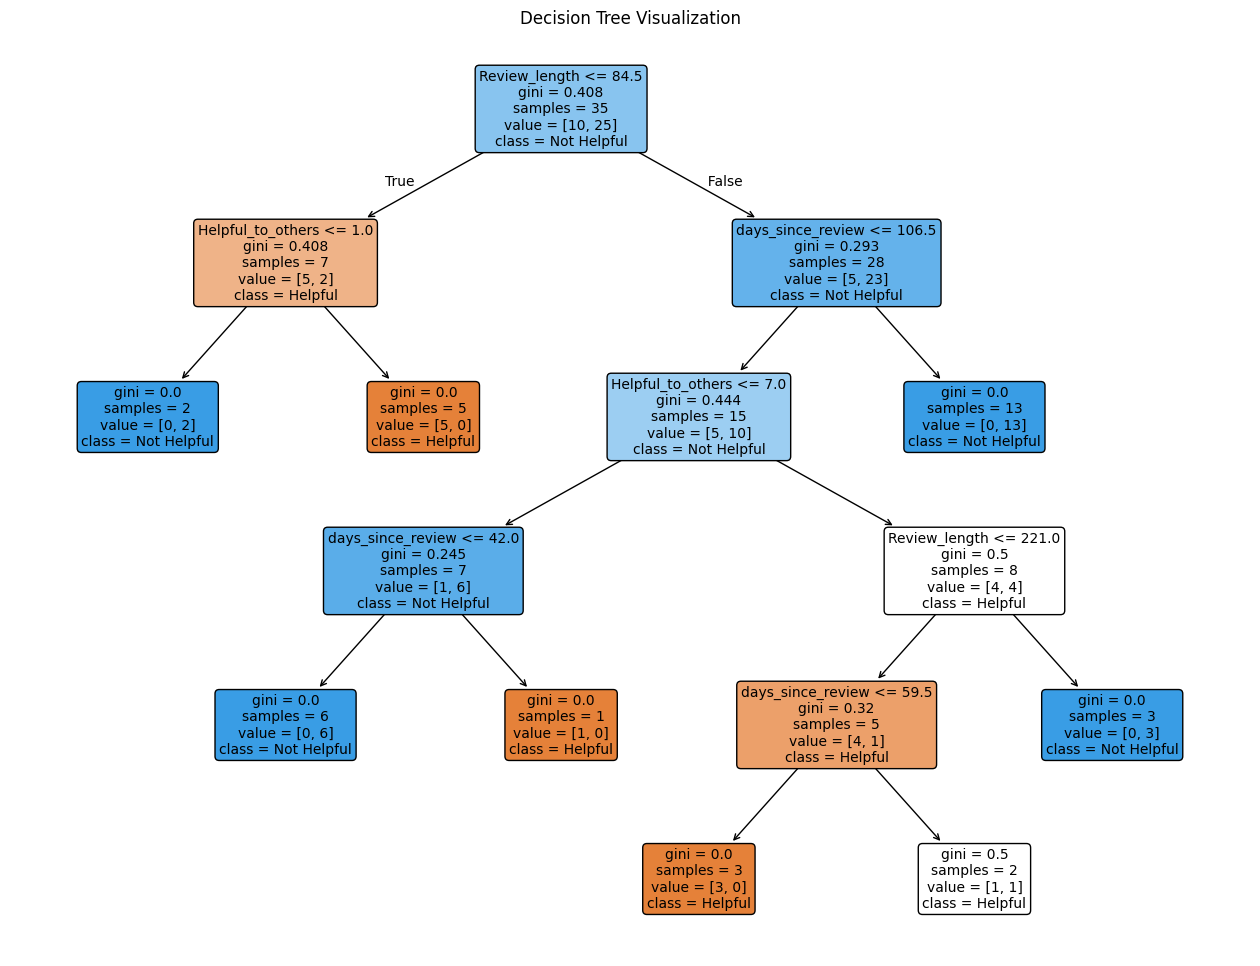

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

#Visualize the decision tree
plt.figure(figsize=(16, 12))
plot_tree(clf, feature_names=list(X.columns), class_names=['Helpful', 'Not Helpful'], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Visualization")
plt.show()

<h2>Evaluation</h2>
<h3>Training Data</h3>
<h4>35 instances</h4>
<ul>
<li>"Not helpful" - 10</li>
<li>"Helpful" - 25</li>
</ul>
<h5>Accuracy</h5>
Highest acheived-97%
</br>The model correctly categorized 97% of the reviews. The f1-score was 95% for the "not helpful" and 98% for the "helpful" predictions.
</br>
<h5>Precision/Recall</h5>
<ul>
<li>Precision rates were 91% and 100% for "not helpful", and "helpful" respectively; the model correctly categorized 91% of reveiws that are not helpful and 100% that are "helpful" (fewer false positives-when the model says it is "not helpful" or "helpful", it is correct).</li>
<li>Recall rates were 100% and 96% for "not helpful" and "helpful" respectively; the model identified 100% of the "not helpful" reviews and 96% of the "helpful" reviews (fewer false negatives-the model missed none of the "not helpful" reviews and missed 4% of the "helpful" reviews).</li>
</ul>
<h3>Validation Data</h3>
<h4>15 instances</h4>
<ul>
<li>"Not helpful" - 10 </li>
<li>"Helpful" - 25 </li>
</ul>
<h5>Accuracy</h5>
Highest achieved - 80%
<h5>Precision</h5>
<ul>
<li>"Not helpful" - 50%</li>
<li>"helpful" - 91%</li>
</ul>
<h5>Recall</h5>
<ul>
<li>"Not helpful" - 67%</li>
<li>"Helpful" - 83%</li>
</ul>
</br>The performance of the training data vs the validation data indicates overfitting. Accuracy dropped 17% from training to validation.
</br>The model was about 3% more accurate in training and 30% more accurate in validation when predicting that a review was "helpful". This is likely a result of the dataset composition of almost 75% reviews that were established as "helpful" to the potential purchaser. This is known as a "majority class" classification; instead of understanding the difference between "helpful" and "not helpful", the model predicts the most common classifier.
</br>The model identified that the features that resulted in a more helpful view were days since the review, reviews being helpful to others, and review length.

<h2>Deployment</h2>
We deployed the model on a sample dataset of four (4) instances.
The model categorized all of the review instances as "helpful". We found three (3) of the reviews "helpful" and one (1) of the reviews "not helpful". This results in 75% accurancy, 100% recall (the model did not miss a positive-no false negatives), and a 75% precision (the model falsely identified a positive). This again is an effect of a majority class classifying error and is likely an effect of overfitting.

In [12]:
#Define the data (Friend's Reviews)
deployment_data = {
    'Review': [
        "I’ve been wearing this ring for two weeks and the accuracy is incredible compared to my watch. It's very comfortable for sleep tracking. Definitely worth the price if you want deep health insights without a screen.",
        "Way too expensive. The heart rate sensor is inaccurate during heavy workouts and the app is glitchy. I'm returning it because the subscription fee is just too high for what you get.",
        "Good ring. Looks nice. It's okay.",
        "After wearing this fitness ring for a month, I’m impressed by the seamless health tracking. Unlike bulky smartwatches, it’s incredibly comfortable for 24/7 wear, especially during sleep. The heart rate and SpO2 accuracy align closely with my medical-grade chest strap. I particularly value the 'Readiness Score,' which helps me decide when to push my workouts or prioritize recovery. The battery life is solid, lasting five days on a single charge. While the initial price is high and the subscription fee is annoying, the deep biometric insights and discreet design make it a worthwhile investment for serious health enthusiasts.",
    ],
    'Helpful_to_others': [0, 0, 0, 0],
    'Star_rating': [5, 2, 4, 5],
    'Prime_eligible': [1, 1, 0, 1],
    'Photos': [0, 0, 0, 0],
    'days_since_review': [4, 4, 3, 2],
    'balanced': [1, 0, 0, 1],
    'only_cons': [0, 1, 0, 0],
    'only_pros': [0, 0, 1, 0]
}

X_new_raw = pd.DataFrame(deployment_data)

#Calculate features for friends' reviews
X_new_raw['Review_length'] = X_new_raw['Review'].apply(lambda x: len(str(x).split()))
X_new_raw['mentions_value'] = X_new_raw['Review'].apply(check_value)

#Define the exact features for training
features = [
    'Helpful_to_others', 'Review_length', 'Star_rating', 'Prime_eligible',
    'Photos', 'mentions_value', 'days_since_review', 'balanced', 'only_cons', 'only_pros'
]

X_new = X_new_raw[features]
predictions = clf.predict(X_new)

#Display the Results
X_new_raw['Prediction'] = predictions
print("--- Decision Tree Deployment Results ---")
print(X_new_raw[['Review', 'Prediction']])

--- Decision Tree Deployment Results ---
                                              Review  Prediction
0  I’ve been wearing this ring for two weeks and ...           1
1  Way too expensive. The heart rate sensor is in...           1
2                  Good ring. Looks nice. It's okay.           1
3  After wearing this fitness ring for a month, I...           1


<h2>Export Clean Data</h2>
Pulling cleaned and modified data for subsequent models

In [13]:
#List of columns to pull
desired_columns = [
    'Helpful_to_others',
    'Review_length',
    'Star_rating',
    'Prime_eligible',
    'Photos',
    'days_since_review',
    'only_cons',
    'only_pros',
    'balanced',
    'mentions_value',
    'Helpful'
]

available_columns = [col for col in desired_columns if col in df.columns]
df[available_columns].to_excel("Amazon_reviews_clean_data.xlsx", index=False)

#Use in Bagging Tree model
print(f"Successfully exported {len(available_columns)} columns to Amazon_reviews_clean_data.xlsx")
if len(available_columns) < len(desired_columns):
    missing = set(desired_columns) - set(available_columns)
    print(f"Note: These columns were missing and skipped: {missing}")

Successfully exported 11 columns to Amazon_reviews_clean_data.xlsx


<h1>Bagging Tree</h1>

In [14]:
#Modeling using bagging
#Load additional package
from sklearn.ensemble import BaggingClassifier

file_path = 'Amazon_reviews_clean_data.xlsx'  #use exported data
df = pd.read_excel(file_path)
print(df.head())
print(df.info())
print(df.describe())



   Helpful_to_others  Review_length  Star_rating  Prime_eligible  Photos  \
0                  6            175            5               1       0   
1                 35            124            5               1       1   
2                 17             44            5               1       1   
3                  9             80            5               1       1   
4                 11             56            5               1       1   

   days_since_review  only_cons  only_pros  balanced  mentions_value  Helpful  
0                 27          0          1         0               1        1  
1                110          0          1         0               1        1  
2                 81          0          1         0               0        0  
3                 66          0          1         0               1        1  
4                 87          0          1         0               1        0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0

In [15]:
y = df['Helpful']
X = df.drop('Helpful', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#Create and train the Bagging Classifier
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(class_weight='balanced'),
    n_estimators=50,
    max_samples=.7,
    max_features=.7,
    random_state=42,
    bootstrap=True
)
bagging_clf.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced'),
                  max_features=0.7, max_samples=0.7, n_estimators=50,
                  random_state=42)

In [16]:
#Evaluate the bagging model
y_pred = bagging_clf.predict(X_train)

#Calculate evaluation metrics
print(f"Training Dataset")
print(f"Bagging Classifier Evaluation Metrics:")
print(classification_report(y_train, y_pred, zero_division=0))

Training Dataset
Bagging Classifier Evaluation Metrics:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.96      1.00      0.98        25

    accuracy                           0.97        35
   macro avg       0.98      0.95      0.96        35
weighted avg       0.97      0.97      0.97        35



In [17]:
#Validation Data
y_pred = bagging_clf.predict(X_test)

#Calculate evaluation metrics
print(f"Validation Dataset")
print(f"Bagging Classifier Evaluation Metrics:")
print(classification_report(y_test, y_pred, zero_division=0))

Validation Dataset
Bagging Classifier Evaluation Metrics:
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         3
           1       0.92      0.92      0.92        12

    accuracy                           0.87        15
   macro avg       0.79      0.79      0.79        15
weighted avg       0.87      0.87      0.87        15



In [18]:
#Read friends' reviews and engineer features

# The X_new_raw DataFrame is created in a previous cell (a1f7e312-2e26-4dfb-9318-e09a1b8a9793)
# with the necessary engineered features (Review_length, mentions_value, etc.).
X_new = X_new_raw[X_train.columns]

new_predictions = bagging_clf.predict(X_new)

#Convert 1s and 0s to readable labels
predicted_classes = ['Helpful' if p == 1 else 'Not_Helpful' for p in new_predictions]

print("\nPredictions for New Data (Bagging Model):")
print("-" * 50)

#Iterate through the new reviews to print the results
for i, row in X_new_raw.iterrows():
    # We display the most important features in the printout
    print(f"Review #{i+1}:")
    print(f"Helpful to others: {row['Helpful_to_others']}, Words: {row['Review_length']}, Days since review posted: {row['days_since_review']}")
    print(f"PREDICTION -> {predicted_classes[i]}")
    print("-" * 50)


Predictions for New Data (Bagging Model):
--------------------------------------------------
Review #1:
Helpful to others: 0, Words: 36, Days since review posted: 4
PREDICTION -> Helpful
--------------------------------------------------
Review #2:
Helpful to others: 0, Words: 32, Days since review posted: 4
PREDICTION -> Helpful
--------------------------------------------------
Review #3:
Helpful to others: 0, Words: 6, Days since review posted: 3
PREDICTION -> Helpful
--------------------------------------------------
Review #4:
Helpful to others: 0, Words: 98, Days since review posted: 2
PREDICTION -> Helpful
--------------------------------------------------


In [19]:
# Deployment
# Predict for new data
# Use X_new which contains only the features used for training
new_predictions = bagging_clf.predict(X_new)
predicted_classes = ['Helpful' if p == 1 else 'Not_Helpful' for p in new_predictions]

print("\nPredictions for New Data:")
for i, row in X_new_raw.iterrows():
    print(f"Helpful to others: {row['Helpful_to_others']}, Words: {row['Review_length']}, Days since review posted: {row['days_since_review']} -> {predicted_classes[i]}")


Predictions for New Data:
Helpful to others: 0, Words: 36, Days since review posted: 4 -> Helpful
Helpful to others: 0, Words: 32, Days since review posted: 4 -> Helpful
Helpful to others: 0, Words: 6, Days since review posted: 3 -> Helpful
Helpful to others: 0, Words: 98, Days since review posted: 2 -> Helpful


<h1>RandomForest</h1>

<h2>Data Processing and Understanding</h2>
The engineered data from the Decision Tree was exported and read into the dataframe for the Random Forest testing. Thus, the same features were available to the RandomForest model.

In [20]:
#Load additional package
from sklearn.ensemble import RandomForestClassifier

file_path = 'Amazon_reviews_clean_data.xlsx'  #Exported data
df = pd.read_excel(file_path)
print(df.head())
print(df.info())
print(df.describe())

   Helpful_to_others  Review_length  Star_rating  Prime_eligible  Photos  \
0                  6            175            5               1       0   
1                 35            124            5               1       1   
2                 17             44            5               1       1   
3                  9             80            5               1       1   
4                 11             56            5               1       1   

   days_since_review  only_cons  only_pros  balanced  mentions_value  Helpful  
0                 27          0          1         0               1        1  
1                110          0          1         0               1        1  
2                 81          0          1         0               0        0  
3                 66          0          1         0               1        1  
4                 87          0          1         0               1        0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0

In [21]:
y = df['Helpful']
X = df.drop('Helpful', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_clf = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
rf_clf.fit(X_train, y_train)

y_pred = rf_clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Random Forest Classifier Metrics:")
print(classification_report(y_test, y_pred))

#Define feature importance
feature_importances = rf_clf.feature_importances_
print("\nFeature Importances:")
for feature, importance in zip(X.columns, feature_importances):
    print(f"{feature}: {importance:.4f}")

#Use only the feature columns (X.columns) from the df for prediction
new_predictions = rf_clf.predict(df[X.columns])
predicted_classes = ['Helpful' if p == 1 else 'Not Helpful' for p in new_predictions]

print("\nPredictions for New Data:")
for i, row in df.iterrows():
    print(f"Helpful to others: {row['Helpful_to_others']}, Words: {row['Review_length']}, Days since review posted: {row['days_since_review']} -> {predicted_classes[i]}")

Random Forest Classifier Metrics:
              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       0.85      0.92      0.88        12

    accuracy                           0.80        15
   macro avg       0.67      0.62      0.64        15
weighted avg       0.78      0.80      0.78        15


Feature Importances:
Helpful_to_others: 0.2117
Review_length: 0.3017
Star_rating: 0.1019
Prime_eligible: 0.0000
Photos: 0.0427
days_since_review: 0.2411
only_cons: 0.0069
only_pros: 0.0387
balanced: 0.0184
mentions_value: 0.0368

Predictions for New Data:
Helpful to others: 6, Words: 175, Days since review posted: 27 -> Helpful
Helpful to others: 35, Words: 124, Days since review posted: 110 -> Helpful
Helpful to others: 17, Words: 44, Days since review posted: 81 -> Not Helpful
Helpful to others: 9, Words: 80, Days since review posted: 66 -> Not Helpful
Helpful to others: 11, Words: 56, Days since review posted: 87 -> Not Helpful

In [22]:
#Input the friends' reviews
new_data = {
    'Review': [
        "I’ve been wearing this ring for two weeks and the accuracy is incredible compared to my watch. It's very comfortable for sleep tracking. Definitely worth the price if you want deep health insights without a screen.",
        "Way too expensive. The heart rate sensor is inaccurate during heavy workouts and the app is glitchy. I'm returning it because the subscription fee is just too high for what you get.",
        "Good ring. Looks nice. It's okay.",
        "After wearing this fitness ring for a month, I’m impressed by the seamless health tracking. Unlike bulky smartwatches, it’s incredibly comfortable for 24/7 wear, especially during sleep. The heart rate and SpO2 accuracy align closely with my medical-grade chest strap. I particularly value the 'Readiness Score,' which helps me decide when to push my workouts or prioritize recovery. The battery life is solid, lasting five days on a single charge. While the initial price is high and the subscription fee is annoying, the deep biometric insights and discreet design make it a worthwhile investment for serious health enthusiasts.",
    ],
    'Helpful_to_others': [0, 0, 0, 0],
    'Star_rating': [5, 2, 4, 5],
    'Prime_eligible': [1, 1, 0, 1],
    'Photos': [0, 0, 0, 0],
    'days_since_review': [4, 4, 3, 2],
    'balanced': [1, 0, 0, 1],
    'only_cons': [0, 1, 0, 0],
    'only_pros': [0, 0, 1, 0]
}

new_df = pd.DataFrame(new_data)

#Include engineered features
new_df['Review_length'] = new_df['Review'].apply(lambda x: len(str(x).split()))
new_df['mentions_value'] = new_df['Review'].apply(check_value)

#Align the engineered features to match feature order of training data
features = [
    'Helpful_to_others', 'Review_length', 'Star_rating', 'Prime_eligible',
    'Photos', 'days_since_review', 'only_cons', 'only_pros', 'balanced', 'mentions_value'
]

X_new = new_df[features]

# 4. Predict using the Bagging Classifier
# This assumes you named your model 'bagging_clf'
bagging_preds = bagging_clf.predict(X_new)

# 5. Add predictions back to the view for your report
new_df['Bagging_Prediction'] = bagging_preds
print(new_df[['Review', 'Bagging_Prediction']])

                                              Review  Bagging_Prediction
0  I’ve been wearing this ring for two weeks and ...                   1
1  Way too expensive. The heart rate sensor is in...                   1
2                  Good ring. Looks nice. It's okay.                   1
3  After wearing this fitness ring for a month, I...                   1


<h2>GradientBoosting Tree</h2>

In [23]:
#Load additional package
from sklearn.ensemble import GradientBoostingClassifier

#Train a Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(
    n_estimators=100,       # Number of boosting stages
    learning_rate=0.1,      # Step size shrinkage
    max_depth=3,            # Maximum depth of individual trees
    min_samples_split=2,    # Minimum samples required to split a node
    min_samples_leaf=1,     # Minimum samples in a leaf node
    random_state=42         # Ensure reproducibility
)
gb_clf.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [24]:
#Evaluate the boosting model
y_pred = gb_clf.predict(X_test)

#Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Gradient Boosting Classifier Metrics:")
print(classification_report(y_test, y_pred))

#Feature Importances
feature_importances = gb_clf.feature_importances_
print("\nFeature Importances:")
for feature, importance in zip(X.columns, feature_importances):
    print(f"{feature}: {importance:.4f}")

Gradient Boosting Classifier Metrics:
              precision    recall  f1-score   support

           0       0.50      0.67      0.57         3
           1       0.91      0.83      0.87        12

    accuracy                           0.80        15
   macro avg       0.70      0.75      0.72        15
weighted avg       0.83      0.80      0.81        15


Feature Importances:
Helpful_to_others: 0.2838
Review_length: 0.4001
Star_rating: 0.0019
Prime_eligible: 0.0000
Photos: 0.0092
days_since_review: 0.2964
only_cons: 0.0000
only_pros: 0.0012
balanced: 0.0000
mentions_value: 0.0073


In [25]:
#Deployment
#Predict for new data
new_predictions = gb_clf.predict(X_new)
predicted_classes = ['Helpful' if p == 1 else 'Not Helpful' for p in new_predictions]

print("\nPredictions for New Data:")
for i, row in new_df.iterrows():
    print(f"Helpful to others: {row['Helpful_to_others']}, Words: {row['Review_length']}, Days since review posted: {row['days_since_review']} -> {predicted_classes[i]}")


Predictions for New Data:
Helpful to others: 0, Words: 36, Days since review posted: 4 -> Helpful
Helpful to others: 0, Words: 32, Days since review posted: 4 -> Helpful
Helpful to others: 0, Words: 6, Days since review posted: 3 -> Helpful
Helpful to others: 0, Words: 98, Days since review posted: 2 -> Helpful
